# Scanpy clustering pipeline

Simple preprocessing → QC → normalization → PCA → UMAP → Leiden clustering at multiple resolutions.

Set `FILE_IDX` below to pick the dataset:
| idx | file | cells |
|-----|------|-------|
| 0 | SRX13198730 | 9,419 |
| 1 | SRX17412841 | 5,506 |
| 2 | SRX22996378 | 3,413 |

## 1. Setup

In [114]:
from __future__ import annotations
from pathlib import Path
import scanpy as sc
import pandas as pd

sc.settings.set_figure_params(dpi=80, figsize=(5, 4), facecolor="white")

H5AD_DIR = Path("../data/scbasecount/2026-01-12/h5ad/GeneFull/Homo_sapiens")
h5ad_files = sorted(H5AD_DIR.glob("*.h5ad"))

FILE_IDX = 2

adata = sc.read(h5ad_files[FILE_IDX])
adata.obs_names_make_unique()
print(adata)

/var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/ipykernel_44677/1987406717.py:6: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, figsize=(5, 4), facecolor="white")


AnnData object with n_obs × n_vars = 3413 × 36601
    obs: 'gene_count_Unique', 'umi_count_Unique', 'gene_count_UniqueAndMult-EM', 'umi_count_UniqueAndMult-EM', 'gene_count_UniqueAndMult-Uniform', 'umi_count_UniqueAndMult-Uniform', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'UniqueAndMult-EM', 'UniqueAndMult-Uniform'


## 2. QC

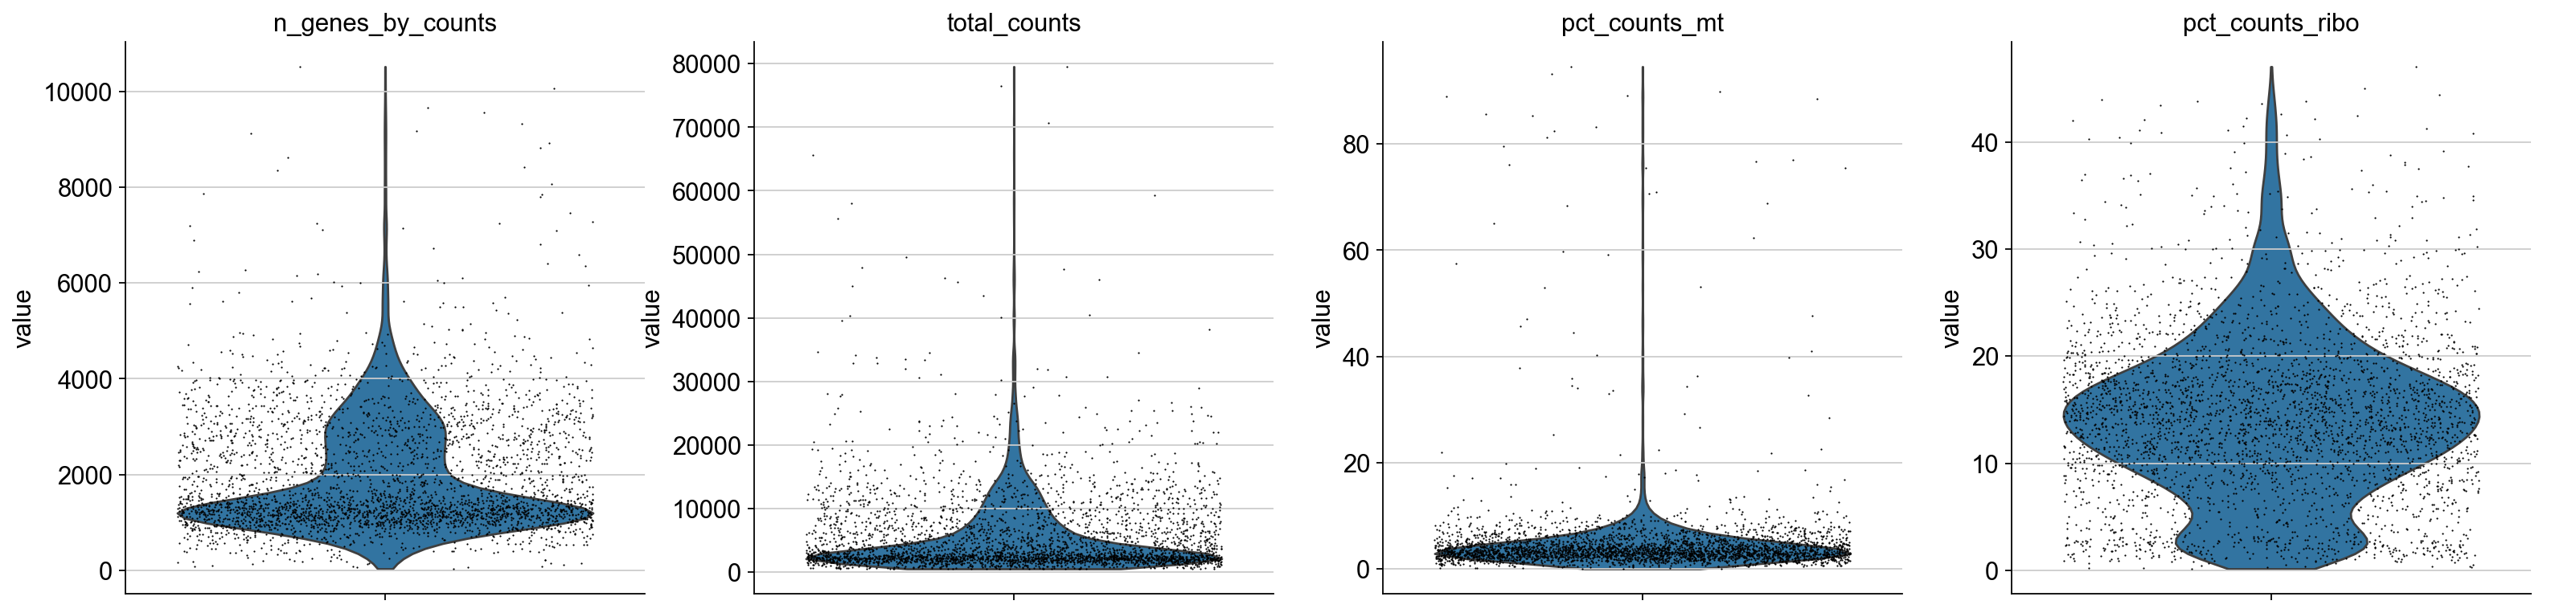

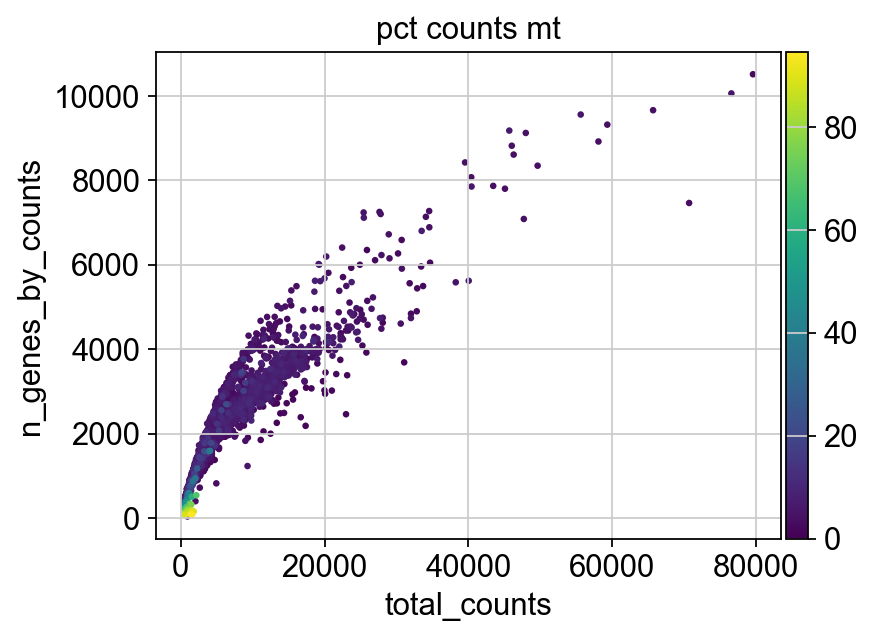

In [115]:
# var_names are ENSEMBL IDs; gene symbols are in adata.var["gene_symbols"]
adata.var["mt"] = adata.var["gene_symbols"].str.startswith("MT-")
adata.var["ribo"] = adata.var["gene_symbols"].str.match(r"^RP[SL]\d")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

In [116]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(adata)

AnnData object with n_obs × n_vars = 3359 × 22908
    obs: 'gene_count_Unique', 'umi_count_Unique', 'gene_count_UniqueAndMult-EM', 'umi_count_UniqueAndMult-EM', 'gene_count_UniqueAndMult-Uniform', 'umi_count_UniqueAndMult-Uniform', 'SRX_accession', 'cell_type', 'cell_ontology_term_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'gene_symbols', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'UniqueAndMult-EM', 'UniqueAndMult-Uniform'


## 3. Preprocessing

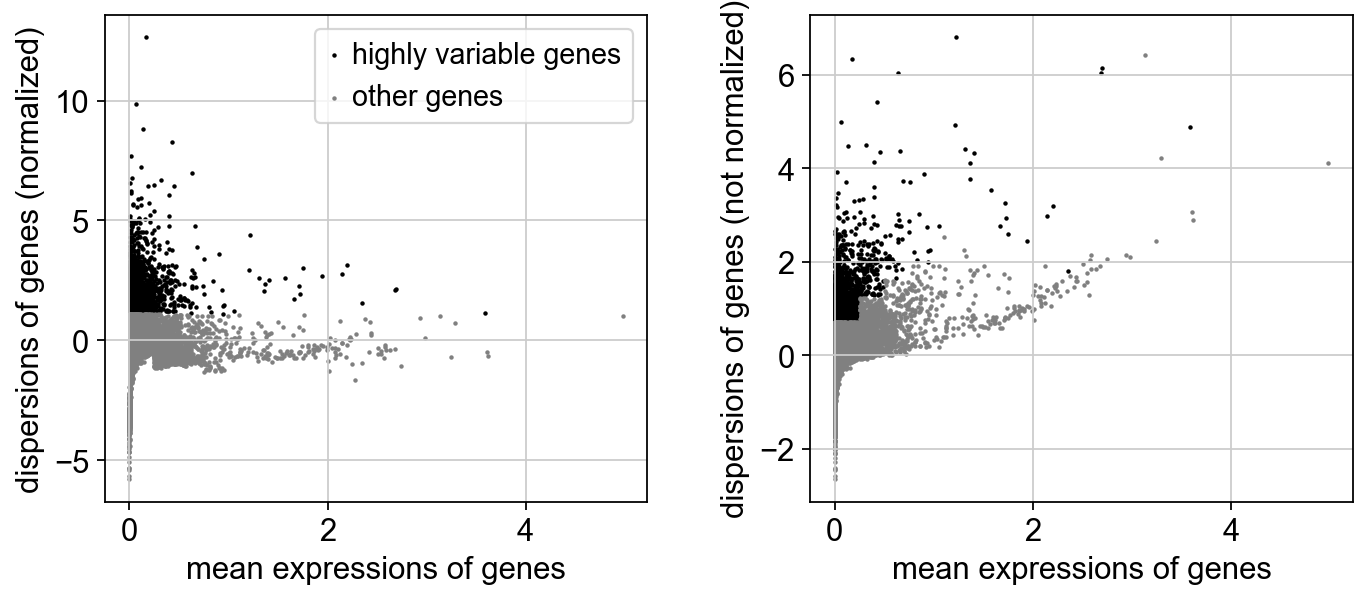

In [117]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

## 4. Dimensionality reduction

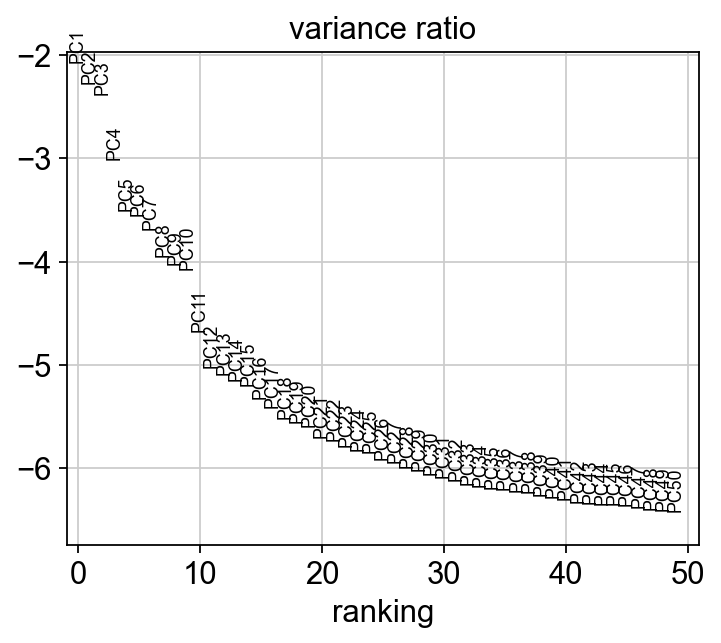

In [118]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [119]:
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)

## 5. Clustering resolutions

Run Leiden at four resolutions. Higher resolution → more (finer) clusters.
`cell_type` is the STATE-algorithm annotation and serves as a weak reference.

In [120]:
RESOLUTIONS = [0.4, 0.6, 0.8, 1.0]

for r in RESOLUTIONS:
    sc.tl.leiden(adata, resolution=r, key_added=f"leiden_{r}")

counts = {
    f"leiden_{r}": adata.obs[f"leiden_{r}"].nunique()
    for r in RESOLUTIONS
}
print(pd.Series(counts, name="n_clusters").to_string())

/var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/ipykernel_44677/36523955.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=r, key_added=f"leiden_{r}")
/var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/ipykernel_44677/36523955.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work

leiden_0.4    15
leiden_0.6    16
leiden_0.8    17
leiden_1.0    20


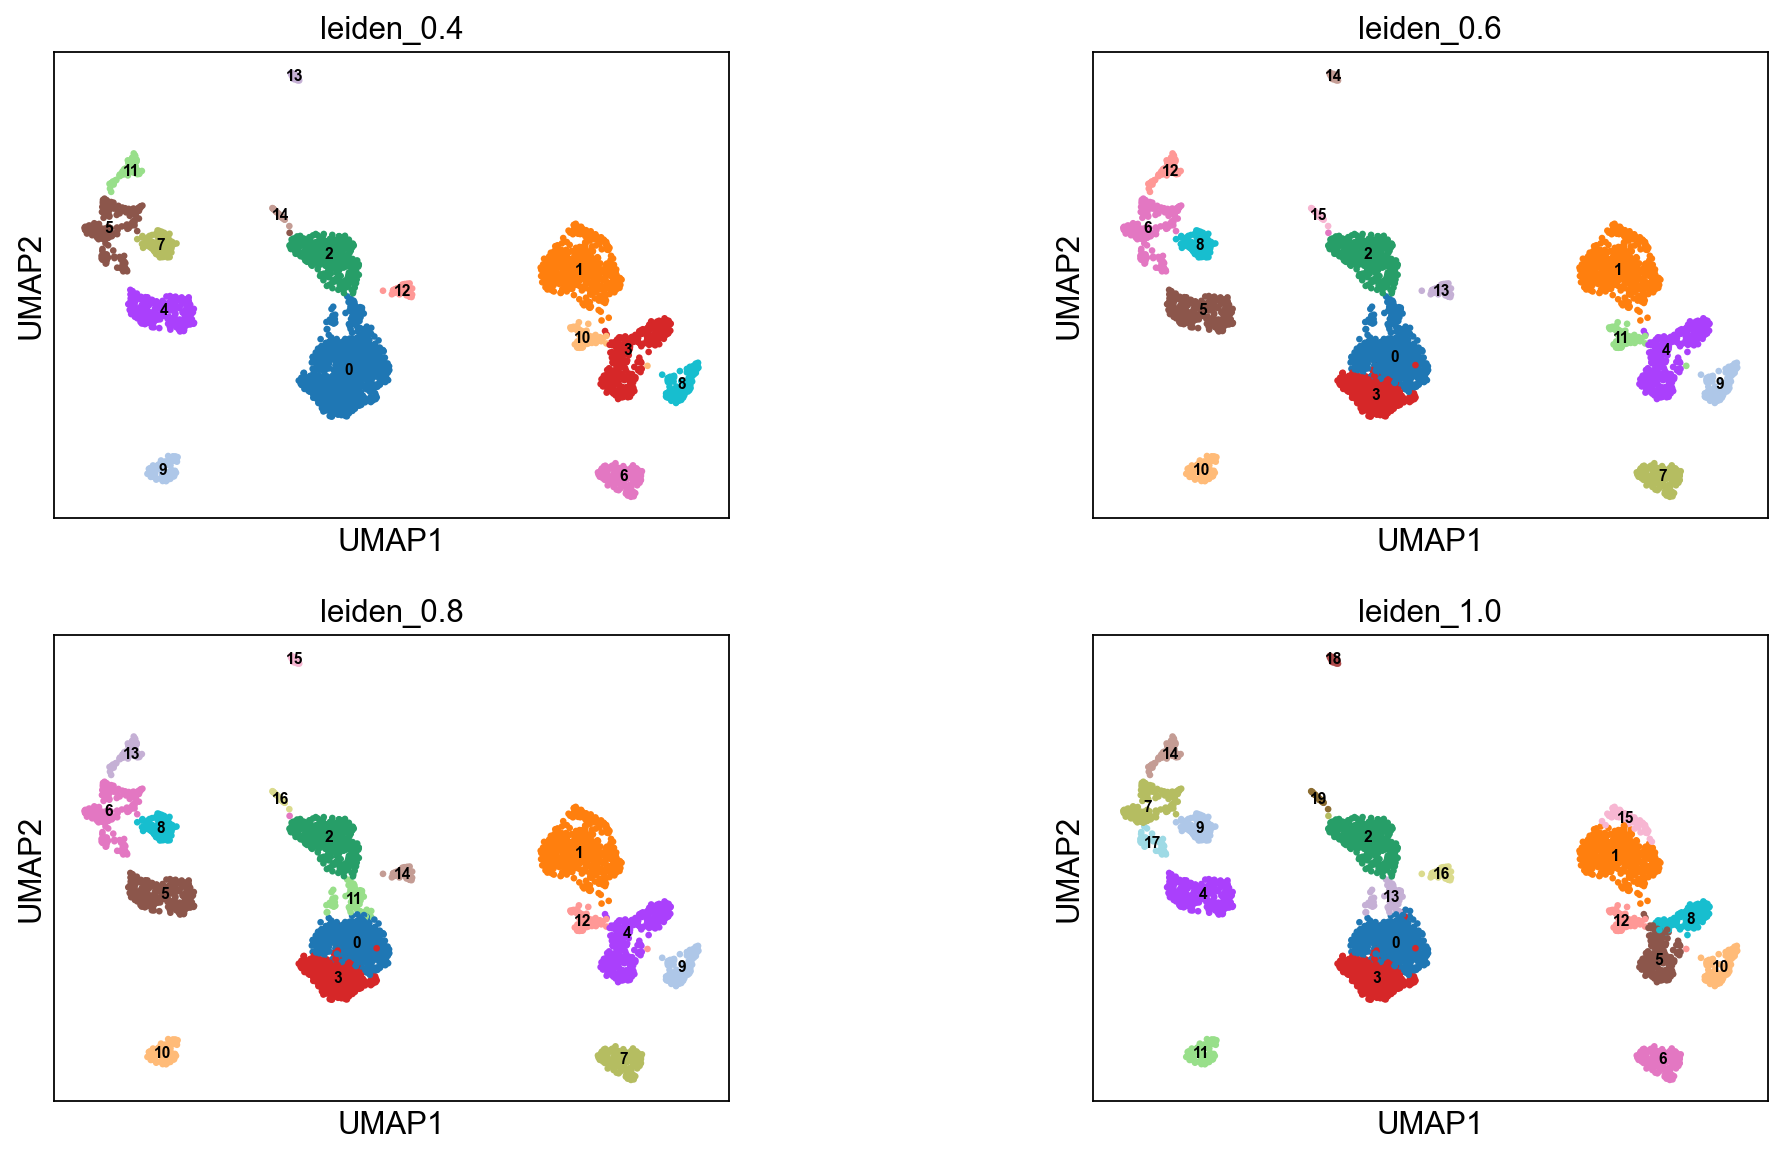

In [121]:
# UMAP colored by each resolution
sc.pl.umap(
    adata,
    color=[f"leiden_{r}" for r in RESOLUTIONS],
    ncols=2,
    legend_loc="on data",
    legend_fontsize=7,
    wspace=0.4,
)

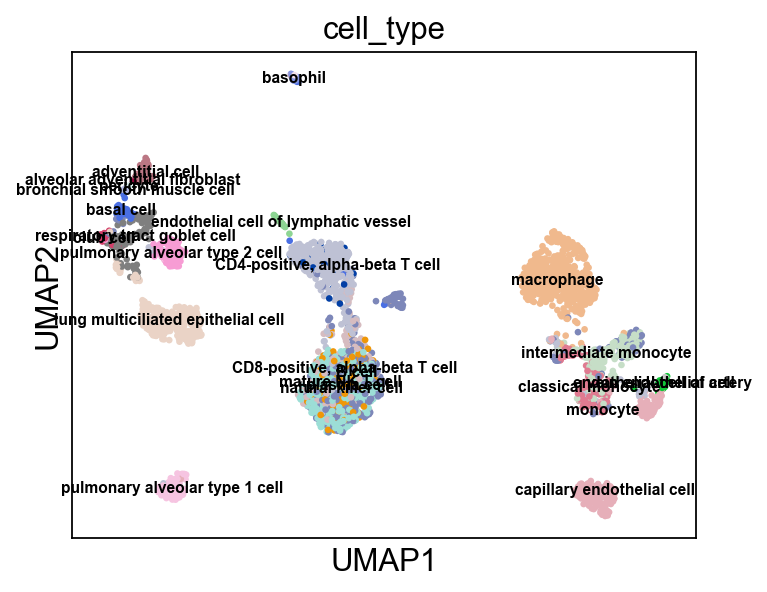

In [122]:
# STATE annotations for reference
sc.pl.umap(adata, color="cell_type", legend_loc="on data", legend_fontsize=7)